# Distribuição Territorial da População

**AUTORIA:** [REDE MOB](https://www.redemob.com.br/)

Este script consolida e apresenta **mapas e estatísticas sociodemográficas** em malha H3 (resolução 9) para os municípios de interesse. Apoia diagnósticos de mobilidade ao espacializar variáveis de população, renda, idade e raça.  

### OBJETIVO

> Construir, a partir de microdados censitários, um conjunto de indicadores espacializados que:
> 1. descrevam a distribuição territorial da população e de suas condições socioeconômicas;  
> 2. sirvam de insumo para análises de equidade, priorização de investimentos e modelos de acessibilidade.

### PANORAMA

- **Leitura de dados:**  
  - Censo Demográfico 2010 e 2022 (IBGE – réplicas no *Base dos Dados*).  
  - Malha H3 derivada dos centroides de setores censitários.  
  - Camada “Área Urbanizada” para delimitação de locais onde há ocupação urbano.  
- **Processamento:** harmonização de dicionários, interseção setor ↦ hexágono (ponderação por área) e cálculo de métricas.  
- **Saídas:** arquivo `parquet` por hexágono, mapas coropléticos (`figures/`) e painéis interativos.

### LIMITAÇÕES

- **Censo 2022:** o Censo apenas liberou dados de rendimento do responsável [até o momento](https://www.ibge.gov.br/novo-portal-destaques/42982-ibge-divulgara-em-30-de-abril-informacoes-do-censo-demografico-2022-sobre-o-rendimento-do-responsavel-pelo-domicilio.html). Com efeito, **não é possível calcular indicadores, como taxa de pobreza e índice de Gini, ou efetuar ranqueamento de divisões territoriais, de acordo com o rendimento**. No entanto, mantivemos a construção de um mapa de população classificado por cores de acordo com o rendimento dos responsáveis por domicílios, pois entendemos que há valor na informação, mas as observações acima devem estar em mente.

### LINKS DE INTERESSE

- IBGE | Censo Demográfico <https://www.ibge.gov.br>  
- Base dos Dados | BigQuery <https://basedosdados.org>  
- Documentação H3 <https://h3geo.org>  


---

## Instruções

Este notebook requer:

1. **Códigos IBGE dos municípios**  
   - Para incluir municípios vizinhos, informe uma lista/tupa de códigos.
2. [**Credenciais de acesso ao BigQuery**](https://basedosdados.org/docs/home#acessando-tabelas-tratadas-bd)
   - Defina a variável de ambiente `GCLOUD_ID` ou insira a _service account key_ correspondente.
3. **Diretório de saída** (`OUTPUT_DIR`)  
   - Caminho onde serão salvos o arquivo `.parquet`, os mapas e demais produtos.  
   - Se omitido, o notebook cria automaticamente a pasta `outputs/` no mesmo diretório do script.


## Definição de Parâmetros

> Na céula a seguir, o usuário deve ajustar os filtros territoriais e temáticos.

| Parâmetro     | Descrição                                   | Exemplo                                   |
|---------------|---------------------------------------------|-------------------------------------------|
| `MUNI_CODES`  | Tupla de códigos IBGE dos municípios-alvo   | `(3300704, 3300258, 3305208)`             |
| `THEMES`      | Blocos temáticos a importar                 | `("basic", "income", "age", "race")`      |
| `H3_RES`      | Resolução da malha H3                       | `9`                                       |
| `OUTPUT_DIR`  | Pasta onde serão salvos os resultados       | `"outputs/"` ou `"/home/usuario/meu_out"` |

```python
# ---- Exemplo 1 --------------------------------------------------------------
GCLOUD_ID   = 'seu-projeto-google-cloud'         # Nome do projeto no Google
MUNI_CODES  = (3300704, 3300258, 3305208)        # Para mais de um município
THEMES      = ("basic", "income", "age", "race") # População, rendimentos, faixas etárias, etnias
H3_RES      = 9                                  # Resolução das "quadrículas"
OUTPUT_DIR  = "outputs"                          # Pasta de "salvamentos"
# -----------------------------------------------------------------------------

# ---- Exemplo 2 --------------------------------------------------------------
GCLOUD_ID   = 'seu-projeto-google-cloud'    # Nome do projeto no Google
MUNI_CODES  = 3300704                       # Para cidade única
THEMES      = ("basic", "age")              # População, faixas etárias
H3_RES      = 7                             # Resolução das "quadrículas"
OUTPUT_DIR  = "outputs"                     # Pasta de "salvamentos"
# -----------------------------------------------------------------------------

## Utilização
1. **Atualize** os parâmetros célula abaixo.  
2. **Execute** todo o notebook. Ele criará a pasta para salvar os resultados armazenará os produtos ali.  
3. **Interprete** os mapas e estatísticas à luz de suas questões de pesquisa ou planejamento.
4. **Role** o notebook para visualizar o passo a passo metodológico em Python: os resultados serão exibidos logo após a seção *backend*. Não é preciso editar o código (não se preocupe), mas ele é mantido para transparência e para que usuários avançados ou curiosos possam manipular procedimentos e compreender a lógica das transformações.

In [ ]:
GCLOUD_ID       = None

MUNI_CODES     = (3300258, 3300209, 3301876, 3305208, 3300233, 3300704)
#MUNI_CODES      = (3303302, 3304904, 3301900)
THEMES          = ("basic", "income", "age", "race")
H3_RES          = 9

OUT_DIR         = "../outputs/sociodemografia"

# Backend

## Bibliotecas e Parâmetros Básicos

In [ ]:
# Standard library
from functools import lru_cache
from io import BytesIO
import gc
import json
import os
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple
import tempfile
import zipfile

# Third-party
import basedosdados as bd
from dotenv import load_dotenv
import geopandas as gpd
import geobr
import mapclassify as mc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express.colors as colors  
import plotly.graph_objects as go
import requests
from statsmodels.stats.weightstats import DescrStatsW
from tobler.area_weighted import area_interpolate
from tobler.util import h3fy

In [ ]:
if not GCLOUD_ID:
    load_dotenv()
    GCLOUD_ID = os.getenv("GCLOUD_ID")


OUT_DIR = Path(OUT_DIR) if OUT_DIR else Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
    
OUT_PARQUET    = (
    OUT_DIR
    / f"sociodemografia_hex_r{H3_RES}_{'-'.join(str(m) for m in MUNI_CODES)}.parquet"
    )

In [ ]:
CFG = {
    "basic": {
        2010: dict(
            table="basedosdados.br_ibge_censo_demografico.setor_censitario_basico_2010",
            cols=dict(v002="habitantes", v001="domicilios"),
        ),
        2022: dict(
            table="basedosdados.br_ibge_censo_2022.setor_censitario",
            cols=dict(pessoas="habitantes", domicilios="domicilios"),
        ),
    },
    "income": {
        2010: dict(
            table="basedosdados.br_ibge_censo_demografico.setor_censitario_basico_2010",
            cols=dict(v009="rendimento_medio"),
        ),
        2022: dict(
            external="_income_2022",   # handled by dedicated fetcher
        ),
    },
    "age": {
        # explicit external fetcher (see §2)
        2010: {"external": "_age_2010"},
        2022: {"external": "_age_2022"},   # stub: returns NaNs
    },

    # ── NEW: self-declared race totals ────────────────────────────────────
    "race": {
        2010: {"external": "_race_2010"},
        2022: {"external": "_race_2022"},  # stub
    },
}

In [ ]:
# Constantes

_BASE = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/"
    "tipologias_do_territorio/areas_urbanizadas_do_brasil"
)

_URL = {
    2005: f"{_BASE}/2019/Shapefile/AreasUrbanizadas2019_Brasil.zip",
    2015: f"{_BASE}/2019/Shapefile/AreasUrbanizadas2019_Brasil.zip",
    2019: f"{_BASE}/2019/Shapefile/AreasUrbanizadas2019_Brasil.zip",
}

INCOME_2022_URL = (
    "https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/"
    "Agregados_por_Setores_Censitarios_Rendimento_do_Responsavel/"
    "Agregados_por_setores_renda_responsavel_BR_csv.zip"
)

TABLE_SETOR_2022 = "basedosdados.br_ibge_censo_2022.setor_censitario"

RACES = ("branca", "preta", "amarela", "parda", "indigena")

In [ ]:

@lru_cache(maxsize=None)
def get_urban_area_gdf(year: int) -> gpd.GeoDataFrame:
    """
    Download IBGE’s national “Área Urbanizada” layer closest to *year*
    (available epochs: 2005, 2015, 2019) and return a GeoDataFrame.

    The function streams the ZIP, extracts to a temporary directory and
    reads the **first** .shp it finds.
    """
    # TODO: adjust below
    epoch = min(_URL, key=lambda k: abs(k - year))     # nearest snapshot
    url   = _URL[2019]
    print(f"🛰  urban footprint {epoch} → {url.split('/')[-1]}")

    with zipfile.ZipFile(BytesIO(requests.get(url, timeout=60).content)) as zf:
        with tempfile.TemporaryDirectory() as tmpdir:
            zf.extractall(tmpdir)
            shp = next(Path(tmpdir).rglob("*.shp"), None)
            if shp is None:
                raise FileNotFoundError("No .shp found inside the archive.")
            return gpd.read_file(shp)


In [ ]:
# ── 0 · helpers ─────────────────────────────────────────────────────────────
def _sql_sum(
    codes: Iterable[int],
    *,
    width: int = 5,
    prefix: str = "V",
    suffix: str = "",
) -> str:
    """
    Build a BigQuery-friendly sum such as
        'V00035 + V00036 + …'
    or, with wrappers,
        'IFNULL(V00035,0) + IFNULL(V00036,0) + …'
    """
    return " + ".join(f"{prefix}{c:0{width}d}{suffix}" for c in codes)


# ── 1 · geometry ────────────────────────────────────────────────────────────
def _urban_mask(year: int, crs: str,
                bbox: tuple[float, float, float, float]) -> gpd.GeoDataFrame:
    """Buffered, dissolved urban footprint clipped to *bbox* (+500 m margin)."""
    minx, miny, maxx, maxy = bbox

    # read, reproject, and bbox-filter FIRST
    urban = (get_urban_area_gdf(year)
             .to_crs(crs)
             .cx[minx:maxx, miny:maxy]
             .geometry.buffer(0)
             )

    if urban.empty:        # unlikely, but avoid empty union errors
        return gpd.GeoDataFrame({"geometry": []}, crs=crs)

    # O buffer de 500 m e apenas para dar uma margem de segurança
    # entre o dado de mancha urbana e a mancha real, que tende a ser um
    # pouco maior, sobretudo porque estamos utilizando 2019
    # já são alguns anos desde esse ano
    union = urban.union_all().buffer(500)
    return gpd.GeoDataFrame({"geometry": [union]}, crs=crs)


def _tracts(
    munis: Iterable[int],
    *,
    year: int,
    clip_to_urban: bool = True,
) -> gpd.GeoDataFrame:
    """Return tracts for *year* with id_setor_censitario as the index."""
    munis = np.atleast_1d(munis).astype(int)
    
    gdf = pd.concat(
        geobr.read_census_tract(code_tract=m, year=year, simplified=False)
        for m in munis
    )
    
    crs = gdf.estimate_utm_crs(datum_name="SIRGAS 2000")
    
    gdf = (
        gdf.assign(id_setor_censitario=lambda d:
                   d.code_tract.astype("int64").astype(str).str.zfill(15))
           .set_index("id_setor_censitario")[["geometry"]]
           
    ).to_crs(crs)

    gdf["geometry"] = gdf.geometry.buffer(0)
    
    print(f"✓ {len(gdf):,} tracts loaded for {year}")

    if clip_to_urban:
        mask = _urban_mask(year, crs, gdf.total_bounds)
        gdf  = (gpd.overlay(gdf.reset_index(), mask, how="intersection")
                  .set_index("id_setor_censitario"))
        gdf  = gdf[gdf.is_valid & ~gdf.is_empty]

    return gdf


# ── 2 · attribute fetchers ──────────────────────────────────────────────────
def _pull_bq(table: str,
             cols: dict[str, str],
             munis: Iterable[int],
             billing: str) -> pd.DataFrame:
    """
    Fetch selected columns for every tract whose municipality (first 7 digits)
    matches *munis*.  Uses only `bd.read_sql`.
    """
    munis_sql  = ", ".join(f"'{int(m):07d}'" for m in munis)
    select_sql = ", ".join(f"{raw} AS {alias}" for raw, alias in cols.items())

    sql = f"""
        SELECT id_setor_censitario, {select_sql}
        FROM {table}
        WHERE SUBSTR(id_setor_censitario, 1, 7) IN ({munis_sql})
    """
    return (bd.read_sql(sql, billing_project_id=billing)
              .set_index("id_setor_censitario"))


@lru_cache
def _income_2022(*_) -> pd.DataFrame:
    """Mean income of household head, sectors – Census 2022 (FTP CSV)."""
    with zipfile.ZipFile(BytesIO(requests.get(INCOME_2022_URL, timeout=60).content)) as zf:
        csv = next(p for p in zf.namelist() if p.endswith(".csv"))
        df = pd.read_csv(
            zf.open(csv),
            sep=";",
            encoding="latin1",
            usecols=["CD_SETOR", "V06004"],
            dtype=str,
        )

    return (
        df.rename(columns={"CD_SETOR": "id_setor_censitario",
                           "V06004": "rendimento_medio"})
          .assign(id_setor_censitario=lambda d: d.id_setor_censitario.str.zfill(15),
                  rendimento_medio=lambda d:
                      pd.to_numeric(d.rendimento_medio.str.replace(",", ".")
                                                     .replace({"X": np.nan, ".": np.nan}),
                                    errors="coerce"))
          .set_index("id_setor_censitario")
    )


def _query_theme(theme: str, year: int,
                 munis: tuple[int], billing: str) -> pd.DataFrame:
    """Return one thematic block for a given year."""
    spec = CFG[theme][year]
    if "external" in spec:
        return globals()[spec["external"]](munis, billing)
    return _pull_bq(spec["table"], spec["cols"], munis, billing)


# ── 3 · assemble one census year ────────────────────────────────────────────
def _census_year(year: int,
                 munis: tuple[int],
                 billing: str,
                 themes: tuple[str],
                 clip_urban: bool = True) -> gpd.GeoDataFrame:

    gdf = _tracts(munis, year=year, clip_to_urban=clip_urban)            # index: id_setor_censitario
    for t in themes:
        gdf = gdf.join(_query_theme(t, year, munis, billing), how="left")
    gdf["year"] = year
    return gdf

# ── 4 · public loader ───────────────────────────────────────────────────────
def import_census_data(
    muni_codes: Iterable[int],
    *,
    gcp_billing: str,
    themes: tuple[str] = ("basic", "income"),
    clip_urban: bool = True,                 # ← expose to the user
) -> gpd.GeoDataFrame:
    muni_codes = tuple(map(int, np.atleast_1d(muni_codes)))
    frames = [_census_year(y, muni_codes, gcp_billing, themes, clip_urban) for y in (2010, 2022)]
    return (pd.concat(frames)
              .set_index("year", append=True))      # MultiIndex: (tract, year)

# ── 5 · hex-aggregation helper (unchanged) ───────────────────────────────────
def aggregate_to_hex(
    src_gdf: gpd.GeoDataFrame,
    hex_gdf: gpd.GeoDataFrame,
    extensive: list[str],
    intensive: list[str] | None = None,
) -> gpd.GeoDataFrame:
    """
    Area-weight the variables in *extensive* (e.g., population, households)
    and *intensive* (e.g., density, average income) from census tracts to an
    H3 grid.

    Both layers must share an equal-area CRS for correct weighting.
    """
    interpolated = area_interpolate(
        source_df=src_gdf,
        target_df=hex_gdf,
        extensive_variables=extensive,
        intensive_variables=intensive,
        allocate_total=True,
    ).drop(columns="geometry")

    out = hex_gdf.join(interpolated)
    return out


# ── 6 · age 2010 (unchanged, but _sql_sum now takes range) ──────────────────
def _age_2010(muni_ids: tuple[int], billing: str) -> pd.DataFrame:
    """
    2010 Universe — four mutually-exclusive age buckets (extensive counts).

    Buckets (IBGE variable codes, inclusive):

      age_0_14  : V022                             # < 1 year
                  + V035–V048    (1- to 14-year-olds)

      age_15_19 : V049–V053      (15- to 19-year-olds)

      age_20_64 : V054–V098      (20- to 64-year-olds)

      age_65p   : V099–V134      (65 years and over)
    """

    muni_list = ", ".join(f"'{m}'" for m in map(str, muni_ids))

    sql = f"""
        SELECT
        id_setor_censitario,

        /* 0–14 years */
        ( IFNULL(v022, 0) +
            {_sql_sum(range(35, 49), width=3, prefix="IFNULL(v", suffix=", 0)")}
        ) AS age_0_14,

        /* 15–19 years */
        (
            {_sql_sum(range(49, 54), width=3, prefix="IFNULL(v", suffix=", 0)")}
        ) AS age_15_19,

        /* 20–64 years */
        (
            {_sql_sum(range(54, 99), width=3, prefix="IFNULL(v", suffix=", 0)")}
        ) AS age_20_64,

        /* 65 + years */
        (
            {_sql_sum(range(99, 135), width=3, prefix="IFNULL(v", suffix=", 0)")}
        ) AS age_65p

        FROM `basedosdados.br_ibge_censo_demografico.setor_censitario_idade_total_2010`
        WHERE SUBSTR(id_setor_censitario, 1, 7) IN ({muni_list})
        """

    df = bd.read_sql(sql, billing_project_id=billing)
    return df.set_index('id_setor_censitario').fillna(0)


# ── 7 · race 2010 (unchanged) ───────────────────────────────────────────────-
def _race_2010(muni_ids: tuple[int], billing: str) -> pd.DataFrame:
    """
    2010 Universe — residents by self-declared colour / race.

      v002  → branca
      v003  → preta
      v004  → amarela
      v005  → parda
      v006  → indigena
    """
    muni_list = ", ".join(f"'{m}'" for m in map(str, muni_ids))

    sql = f"""
        SELECT
          id_setor_censitario,
          v002 AS race_branca,
          v003 AS race_preta,
          v004 AS race_amarela,
          v005 AS race_parda,
          v006 AS race_indigena
        FROM
          `basedosdados.br_ibge_censo_demografico.setor_censitario_raca_idade_genero_2010`
        WHERE
          SUBSTR(id_setor_censitario, 1, 7) IN ({muni_list})
    """

    df = bd.read_sql(sql, billing_project_id=billing)
    return df.set_index('id_setor_censitario').fillna(0)


# ── 8 · age 2022  ------------------------------------------------------------
def _age_2022(munis: tuple[int], billing: str) -> pd.DataFrame:
    """Four age buckets matching 2010 definitions – Census 2022."""
    muni_sql = ", ".join(f"'{int(m):07d}'" for m in munis)
    blk_20_64 = _sql_sum(range(645, 654), width=5,
                     prefix="IFNULL(V", suffix=", 0)")
    blk_65p   = _sql_sum((654, 655, 656),  width=5,
                     prefix="IFNULL(V", suffix=", 0)")

    sql = f"""
      SELECT
        id_setor_censitario,
        pessoas                  AS total_pop,
        V00644                   AS age_15_19,
        ({blk_20_64})            AS age_20_64,
        ({blk_65p})              AS age_65p
      FROM `{TABLE_SETOR_2022}`
      WHERE SUBSTR(id_setor_censitario, 1, 7) IN ({muni_sql})
    """
    df = bd.read_sql(sql, billing_project_id=billing).fillna(0)
    df["age_0_14"] = df["total_pop"] - df[["age_15_19", "age_20_64", "age_65p"]].sum(axis=1)
    return df.drop(columns="total_pop").set_index("id_setor_censitario")

# ── 9 · race 2022  -----------------------------------------------------------
def _race_2022(muni_ids: tuple[int], billing: str) -> pd.DataFrame:
    """All-ages race totals, 2022, with <15 cohort imputed from municipal mix."""
    muni_sql = ", ".join(f"'{int(m):07d}'" for m in muni_ids)

    # blocks
    pop_15p_sql = _sql_sum(
        range(644, 657),                 # V00644–V00656
        prefix="IFNULL(V", suffix=",0)"
        )
        
    race_block  = lambda off: _sql_sum(
        (b + off for b in range(657, 717, 5)),
        prefix="IFNULL(V", suffix=",0)"
        )
    races_15p_sql = ",\n".join(f"({race_block(i)}) AS race_{r}_15p"
                               for i, r in enumerate(RACES))

    sql = f"""
      SELECT id_setor_censitario,
             pessoas                     AS total_pop,
             ({pop_15p_sql})             AS pop_15p,
             {races_15p_sql}
      FROM `{TABLE_SETOR_2022}`
      WHERE SUBSTR(id_setor_censitario, 1, 7) IN ({muni_sql})
    """
    df = bd.read_sql(sql, billing_project_id=billing).fillna(0)

    # derive <15 pop
    df["age_0_14"] = df["total_pop"] - df["pop_15p"]
    df["id_mun"]   = df["id_setor_censitario"].str.slice(0, 7)

    race_cols = [f"race_{r}_15p" for r in RACES]
    grouped   = df.groupby("id_mun")[race_cols + ["pop_15p"]].sum()

    muni_share = grouped[race_cols].div(grouped["pop_15p"], axis=0)

    for r in RACES:
        df[f"race_{r}"] = (
            df[f"race_{r}_15p"] +
            df["age_0_14"] * df["id_mun"].map(muni_share[f"race_{r}_15p"])
        )

    return (df.set_index(df.id_setor_censitario.str.zfill(15))
              [[f"race_{r}" for r in RACES]])


In [ ]:
def add_income_deciles(
    hex_long: gpd.GeoDataFrame,
    *,
    income_col: str = "rendimento_medio",
    pop_col: str = "habitantes",
    out_col: str = "decile",
) -> gpd.GeoDataFrame:
    """
    Append a population-weighted income decile (1–10) to *hex_long*.

    The cut-points are computed with statsmodels' DescrStatsW.quantile,
    separately for each census year.
    """
    probs = np.linspace(0.1, 0.9, 9)        # 10-quantile breakpoints 10 %, …, 90 %

    def _by_year(df: pd.DataFrame) -> pd.DataFrame:
        # 1 ─ get weighted quantiles (automatically handle duplicates/NaN)
        dsw = DescrStatsW(df[income_col], weights=df[pop_col], ddof=0)
        q = dsw.quantile(probs, return_pandas=False)

        # 2 ─ build edges  (−∞, q1, q2, …, q9, +∞)
        edges = np.concatenate(([-np.inf], q, [np.inf]))

        # 3 ─ classify every hexagon  → 1 … 10
        df[out_col] = pd.cut(
            df[income_col],
            bins=edges,
            labels=range(1, 11),
            right=False,           # [edge, next)
            include_lowest=True,
            duplicates="drop",     # safe if some q collapse
        )
        return df

    return (
        hex_long
        .dropna(subset=[income_col, pop_col])     # rows with NaN income are ignored
        .groupby("year", group_keys=False)
        .apply(_by_year)
        .astype({out_col: "Int8"})                # tidy dtype
    )



In [ ]:
# ── 6 · Pipeline execution ────────────────────────────────────────────────
if __name__ == "__main__":
    tracts_long = import_census_data(
        MUNI_CODES, gcp_billing=GCLOUD_ID, themes=THEMES, clip_urban=True
    )

    # ── 6·1 build a single H3 grid covering all tracts ────────────────────
    hex_grid = h3fy(tracts_long, H3_RES)

    # ── 6·2 declare what is intensive once, derive extensive ------------- 
    INTENSIVE = {"rendimento_medio"}     # mean income values
    EXTENSIVE = [
        col for col in tracts_long.columns
        if col not in INTENSIVE and col != "geometry"
    ]

    # ── 6·3 aggregate each census year to H3 ─────────────────────────────
    # TODO: adjust functions above to avoid .fillna(0) here
    hex_long = (
        tracts_long
        .fillna(0)                        # Tobler propagates unnatended NaNs
        .groupby("year")
        .apply(
            lambda g: aggregate_to_hex(
                g,
                hex_grid,
                extensive=EXTENSIVE,
                intensive=list(INTENSIVE),
            )
        )
        .reset_index(level=0) # keep “year” as a column
        .round()
    )

hex_long  = add_income_deciles(hex_long)


hex_long.to_parquet(OUT_PARQUET)


# Visualizações

In [ ]:
SLIDER_STYLE = dict(
    len=0.25,
    x=0.75,
    xanchor="center",
    y=1,
    yanchor="bottom",
    pad={"t": 20, "b": 10},
)
DROPDOWN_STYLE = dict(
    x=0.01,
    xanchor="left",
    y=1.0,
    yanchor="bottom",
    pad={"r": 6, "t": 5},
)
COLORBAR_STYLE = dict(thickness=12, len=0.75)


def fresh_plot(fig=None):
    """
    Clears memory of the previous figure before returning a new one.
    Pass an existing fig to render, or call without args before creating a new fig.
    """
    if fig is None:
        gc.collect()
        return None
    else:
        fig.show(config={"scrollZoom": True})
        del fig
        gc.collect()


def _prepare_geodata(
    gdf: gpd.GeoDataFrame, id_col: str, year_col: str, vars_to_show: List[str]
) -> Tuple[gpd.GeoDataFrame, Dict, List[str], List[int]]:
    """
    Prepares the GeoDataFrame and extracts the base GeoJSON for the map.
    """
    cols_needed = [year_col, id_col, "geometry", *vars_to_show]
    gdf = gdf[cols_needed].dropna(subset=[id_col, "geometry"]).copy()
    gdf = gdf.to_crs(4326)
    gdf[id_col] = gdf[id_col].astype(str)

    # Ensure consistent integer-like year ordering even if dtype is object
    years = sorted(pd.unique(gdf[year_col].astype(int)).tolist())

    geo_base = (
        gdf[[id_col, "geometry"]]
        .drop_duplicates(subset=[id_col])
        .set_index(id_col)
        .sort_index()
    )

    # Keep the ID as a property in the GeoJSON
    geojson = json.loads(geo_base.reset_index().to_json())
    locs = geo_base.index.astype(str).tolist()

    return gdf, geojson, locs, years


def _labels_from_bins(bins: np.ndarray) -> List[str]:
    """
    Build readable class labels from ascending bin edges (exclusive left, inclusive right).
    For bins = [b1, b2, ..., bk], labels are:
      '≤ b1', '(b1, b2]', '(b2, b3]', ..., '(b_{k-1}, b_k]'
    """
    labels = [f"≤ {bins[0]:.2f}"]
    for a, b in zip(bins[:-1], bins[1:]):
        labels.append(f"({a:.2f}, {b:.2f}]")
    return labels


def _calculate_variable_specs(
    gdf: gpd.GeoDataFrame,
    vars_to_show: List[str],
    id_col: str,
    year_col: str,
    locs: List[str],
    years: List[int],
    clip_q: Optional[Tuple[float, float]],
    log_color: bool,
    scheme: Optional[str],
    k: int,
    scheme_kwargs: Optional[Dict],
    colorscale: str,
) -> Tuple[Dict[str, Dict[int, Dict[str, np.ndarray]]],
           Dict[str, Dict[int, Dict[str, Any]]]]:
    """
    Pre-compute (per variable, per year):
      - the plotted z-array (continuous or class indices)
      - the raw values (for hover)
      - the color-axis spec (continuous min/max OR discrete bins/labels/colorscale)
    """
    var_specs: Dict[str, Dict[int, Dict[str, Any]]] = {v: {} for v in vars_to_show}
    data_cache: Dict[str, Dict[int, Dict[str, np.ndarray]]] = {v: {} for v in vars_to_show}

    for var in vars_to_show:
        # id x year table for this variable, ordered to match "locs"
        pivot_df = gdf.pivot(index=id_col, columns=year_col, values=var)
        pivot_df.columns = pivot_df.columns.astype(int)
        pivot_df = pivot_df.reindex(locs)

        for yr in years:
            s_raw = pd.to_numeric(pivot_df.get(yr), errors="coerce")

            # Per-(var,year) clipping like many GIS defaults
            if clip_q:
                lo, hi = s_raw.quantile(list(clip_q))
                s_clip = s_raw.clip(lo, hi)
            else:
                s_clip = s_raw.copy()

            # Optional transform applied per-(var,year)
            if log_color:
                z_cont = np.log10(np.clip(s_clip.to_numpy(dtype=float), 1e-12, None))
            else:
                z_cont = s_clip.to_numpy(dtype=float)

            finite_mask = np.isfinite(z_cont)
            finite_vals = z_cont[finite_mask]

            # Build the spec for this (var,year)
            spec: Dict[str, Any] = {"log_color": log_color, "title": var}

            if scheme and finite_vals.size >= 2 and (mc is not None):
                # Defensive: reduce k if too few distinct values
                nunique = np.unique(finite_vals).size
                k_eff = max(1, min(k, nunique))
                if k_eff == 1:
                    # Fall back to continuous with tiny span
                    cmin = float(np.nanmin(finite_vals)) if finite_vals.size else 0.0
                    cmax = cmin + 1e-9
                    data_cache[var][yr] = {"raw": s_raw.to_numpy(), "z": z_cont}
                    spec.update({"type": "continuous", "cmin": cmin, "cmax": cmax, "colorscale": colorscale})
                else:
                    klass = mc.classify(finite_vals, scheme=scheme, k=k_eff, **(scheme_kwargs or {}))
                    bins = np.asarray(klass.bins, dtype=float)  # length = k_eff
                    # Digitize the *whole* array (NaNs remain NaN)
                    z_idx = np.full_like(z_cont, fill_value=np.nan, dtype=float)
                    z_idx[finite_mask] = np.digitize(finite_vals, bins=bins, right=True).astype(float)
                    labels = _labels_from_bins(bins)
                    positions = np.linspace(0, 1, k_eff)
                    disc_colors = colors.sample_colorscale(colorscale, positions)
                    spec.update({
                        "type": "discrete",
                        "k": k_eff,
                        "labels": labels,
                        "colorscale": [[i / max(1, (k_eff - 1)), c] for i, c in enumerate(disc_colors)],
                    })
                    data_cache[var][yr] = {"raw": s_raw.to_numpy(), "z": z_idx}
            else:
                # Continuous per-(var,year) (closest to GeoPandas .explore default)
                if finite_vals.size == 0:
                    cmin, cmax = 0.0, 1.0
                else:
                    cmin = float(np.nanmin(finite_vals))
                    cmax = float(np.nanmax(finite_vals))
                    if not np.isfinite(cmin): cmin = 0.0
                    if not np.isfinite(cmax): cmax = cmin + 1.0
                    if cmin == cmax:
                        cmax = cmin + 1e-9  # avoid zero-span color scales
                spec.update({"type": "continuous", "cmin": cmin, "cmax": cmax, "colorscale": colorscale})
                data_cache[var][yr] = {"raw": s_raw.to_numpy(), "z": z_cont}

            var_specs[var][yr] = spec

    return data_cache, var_specs


def _build_coloraxis(spec: Dict[str, Any]) -> Dict:
    """Builds a coloraxis dictionary from a variable-year specification."""
    title_suffix = " (log10)" if spec["log_color"] else ""
    colorbar = {**COLORBAR_STYLE, "title": spec["title"] + title_suffix}

    if spec["type"] == "discrete":
        colorbar.update(
            tickmode="array",
            tickvals=list(range(spec["k"])),
            ticktext=spec["labels"],
        )
        return dict(
            cmin=-0.5,
            cmax=spec["k"] - 0.5,
            colorscale=spec["colorscale"],
            colorbar=colorbar,
        )
    else:  # continuous
        return dict(
            cmin=spec["cmin"],
            cmax=spec["cmax"],
            colorscale=spec["colorscale"],
            colorbar=colorbar,
        )


def _visibility_mask(num_vars: int, num_years: int, var_idx: int, year_idx: int) -> List[bool]:
    """Helper: visibility vector that shows only (var_idx, year_idx)."""
    mask = [False] * (num_vars * num_years)
    mask[var_idx * num_years + year_idx] = True
    return mask


def hexmap_slider_dropdown(
    gdf: gpd.GeoDataFrame,
    *,
    year_col: str = "year",
    id_col: str = "hex_id",
    vars_to_show: List[str] = ("habitantes",),
    map_height: int = 700,
    tiles: str = "open-street-map",
    colorscale: str = "RdYlBu",
    opacity: float = 0.7,
    clip_q: Optional[Tuple[float, float]] = None,   # ← set to None to match .explore behavior
    log_color: bool = False,
    mapbox_zoom: Optional[float] = None,
    title_prefix: str = "Mapa | ",
    scheme: Optional[str] = None,
    k: int = 5,
    scheme_kwargs: Optional[Dict] = None,
) -> go.Figure:
    """
    Creates an interactive choropleth map with a year slider and a
    variable dropdown (one legend/colorscheme per (variable × year)).
    """
    # 1) Data and per-(var,year) specs
    gdf_proc, geojson, locs, years = _prepare_geodata(gdf, id_col, year_col, list(vars_to_show))
    data_cache, var_specs = _calculate_variable_specs(
        gdf_proc, list(vars_to_show), id_col, year_col, locs, years,
        clip_q, log_color, scheme, k, scheme_kwargs, colorscale,
    )

    # 2) Figure + one coloraxis per (var,year)
    fig = go.Figure()
    num_vars = len(vars_to_show)
    num_years = len(years)

    axis_name = {}
    axis_counter = 1
    for i, var in enumerate(vars_to_show):
        for j, yr in enumerate(years):
            name = f"coloraxis{axis_counter}"
            axis_name[(i, j)] = name
            fig.layout[name] = _build_coloraxis(var_specs[var][yr])
            axis_counter += 1

    # 3) All traces (one per (var,year)), attach their own coloraxis
    for i, var in enumerate(vars_to_show):
        for j, yr in enumerate(years):
            is_first = (i == 0 and j == 0)
            fig.add_trace(
                go.Choroplethmap(               # If your Plotly version lacks this, use go.Choroplethmapbox + mapbox_* keys.
                    locations=locs,
                    z=data_cache[var][yr]["z"],
                    customdata=data_cache[var][yr]["raw"],
                    geojson=geojson,
                    featureidkey=f"properties.{id_col}",
                    coloraxis=axis_name[(i, j)],
                    marker_line_width=0,
                    visible=is_first,
                    hovertemplate=(
                        f"%{{location}}<br>{var} ({yr}): "
                        "%{customdata:,.0f}<extra></extra>"
                    ),
                )
            )

    # 4) Build one slider *per variable*, each showing that variable’s traces only
    sliders_by_var = {}
    for i, var in enumerate(vars_to_show):
        steps = []
        for j, yr in enumerate(years):
            vis = _visibility_mask(num_vars, num_years, i, j)
            steps.append(dict(
                label=str(yr),
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{title_prefix}{var} — {yr}"}
                ],
            ))
        sliders_by_var[var] = [dict(**SLIDER_STYLE, active=0, steps=steps)]

    # 5) Dropdown that (i) shows var at its first year and (ii) swaps in the right slider
    dropdown_buttons = []
    for i, var in enumerate(vars_to_show):
        vis = _visibility_mask(num_vars, num_years, i, 0)
        dropdown_buttons.append(dict(
            label=var,
            method="update",
            args=[
                {"visible": vis},                                  # data update
                {"sliders": sliders_by_var[var],                   # layout update: swap slider
                 "title": f"{title_prefix}{var} — {years[0]}"}     # title
            ],
        ))

    # 6) Final layout
    xmin, ymin, xmax, ymax = gdf_proc.total_bounds
    fig.update_layout(
        height=map_height,
        title=f"{title_prefix}{vars_to_show[0]} — {years[0]}",
        map_style=tiles,               # new 'map' keys; for mapbox use mapbox_style, mapbox_center, mapbox_zoom
        map_center={"lon": (xmin + xmax) / 2, "lat": (ymin + ymax) / 2},
        map_zoom=mapbox_zoom if mapbox_zoom is not None else 10,
        updatemenus=[dict(**DROPDOWN_STYLE, active=0, buttons=dropdown_buttons)],
        sliders=sliders_by_var[vars_to_show[0]],
        margin=dict(l=0, r=0, t=80, b=0),
        showlegend=False,
    )
    fig.update_traces(marker_opacity=opacity)
    return fig


In [ ]:
fresh_plot()

fig = hexmap_slider_dropdown(
    gdf=hex_long.reset_index(),
    year_col="year",
    id_col="hex_id",
    vars_to_show=hex_long.columns[2:].tolist(),
    map_height=700,
    tiles="carto-positron",
    colorscale="RdYlBu",
    #opacity=0.9,
    clip_q=None,
    title_prefix="Mapa | Ano: ",
    scheme='headtailbreaks',
    #k=7,
    #scheme_kwargs=None,
)

fresh_plot(fig)

In [ ]:
hex_long.habitantes.plot.hist(bins=50)

# Variação Populacional

In [ ]:
def eb_smooth(y: pd.Series, n: pd.Series) -> pd.Series:
    """
    Empirical-Bayes posterior mean of a Poisson count *y*
    observed over exposure *n* (here n ≡ 1 so it is plain counts).

    Formula   μ̂ᵢ = (α / (α+β)) · θ̄  +  (β / (α+β)) · θᵢ
    with α,β the method-of-moments Gamma prior parameters.
    """
    y = y.fillna(0).astype(float)
    n = n.astype(float)

    rate = y / n
    m    = rate.mean()
    v    = rate.var(ddof=1)

    # method-of-moments Γ(a,b) prior on the rate
    a = m ** 2 / v if v > 0 else 1.0
    b = m / v      if v > 0 else 1.0

    post_mean = (y + a) / (n + b)
    return post_mean.rename("habitantes_EB")

def add_eb_smoothed_counts(hex_long: gpd.GeoDataFrame,
                           count_col: str = "habitantes",
                           year_col: str = "year") -> gpd.GeoDataFrame:
    """Adds an Empirical-Bayes smoothed *count_col* for every year."""
    def _per_year(df):
        df["habitantes_EB"] = eb_smooth(df[count_col], n=pd.Series(1, index=df.index))
        return df

    return (hex_long
            .groupby(year_col, group_keys=False)
            .apply(_per_year))

hex_long = add_eb_smoothed_counts(hex_long)

delta = (hex_long.pivot_table(index=hex_long.index,   # hex_id
                              columns="year",
                              values="habitantes_EB")
                   .rename(columns={2010: "pop10", 2022: "pop22"})
                   .assign(pop_delta=lambda d: d["pop22"] - d["pop10"])
                   .dropna(subset=["pop_delta"]))

# attach geometry once – any year is fine
delta = delta.join(hex_long.drop_duplicates("geometry")[["geometry"]])

delta = delta.loc[(hex_long.groupby(level=0)["habitantes_EB"].sum() > 50)]

q = delta["pop_delta"].quantile([0.01, 0.99])
delta["pop_delta_clip"] = delta["pop_delta"].clip(q.iloc[0], q.iloc[1])

delta = gpd.GeoDataFrame(delta,
                         geometry="geometry",
                         crs=hex_long.crs)     # inherit original CRS

delta.explore(
    column="pop_delta_clip",
    scheme="FisherJenks",
    cmap="coolwarm_r",
    legend=True,
    tooltip=["pop_delta"],
    tiles="Carto DB positron"
)


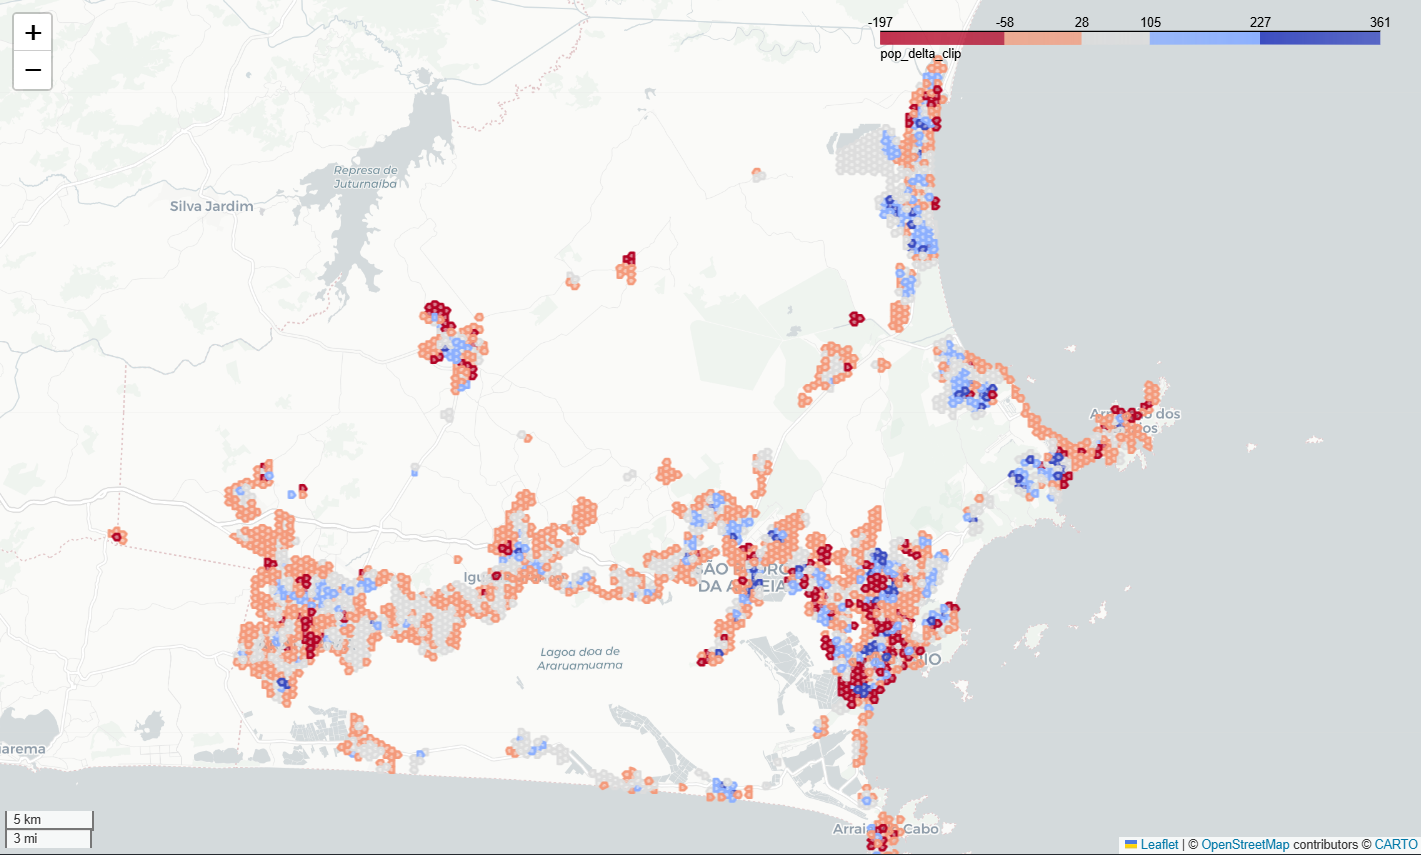

# Projeções da População

In [ ]:
POP_PROJECTION_URL = (
    "https://ftp.ibge.gov.br/Projecao_da_Populacao/"
    "Projecao_da_Populacao_2024/"
    "projecoes_2024_tab3_grupos_etarios_especificos.xlsx"
)


def read_pop_projections() -> pd.DataFrame:
    """
    Download and process population projections data from IBGE.

    Returns:
        pd.DataFrame: A DataFrame with columns 'id_setor_censitario' and
                      'rendimento_medio'.
    """
    return pd.read_excel(
        POP_PROJECTION_URL,
        skiprows=6,
        usecols="A:G,N:P,Z:AB, AF:AH",
    )

In [ ]:
def filter_states(df, siglas):
    siglas = [siglas] if isinstance(siglas, str) else siglas
    return df[df["SIGLA"].isin(siglas)].copy()


def filter_years(df, start=None, end=None):
    if start:
        df = df[df["ANO"] >= start]
    if end:
        df = df[df["ANO"] <= end]
    return df


def _has_digits(s):
    return bool(re.search(r"\d|POP", s))


def _ends_with_any(suffixes):
    return lambda s: any(s.endswith(sfx) for sfx in suffixes)


def _starts_with(prefix):
    return lambda s: s.startswith(prefix)


def select_columns(df, by_age=False, gender=False):
    cols = df.columns
    base = _has_digits if by_age else _starts_with("POP")
    suffixes = ["_M", "_H"] if gender else ["_T"]
    suffix = _ends_with_any(suffixes)
    return [col for col in cols if base(col) and suffix(col)]


def rename_columns(cols):
    gender_map = {"_H": "Homens", "_M": "Mulheres", "_T": "Total"}

    def rename(col):
        for sfx, g in gender_map.items():
            if col.endswith(sfx):
                base = col.removesuffix(sfx)
                return f"{base} • {g}" if re.search(r"\d", base) else g
        return col

    return {col: rename(col) for col in cols}


def reshape_for_plot(df, columns):
    labels = rename_columns(columns)
    melted = df.melt(
        id_vars=["ANO", "SIGLA"],
        value_vars=columns,
        var_name="Grupo",
        value_name="População"
    )
    melted["Grupo"] = melted["Grupo"].map(labels)
    melted["População"] = melted["População"] / 1_000  # scale to thousands
    return melted


def render_plot(plot_df, hue_order, title, height, out_path):
    """Render a high-quality plot for A4 PDF output."""
    a4_width = 11.7  # inches (landscape A4)
    dpi = 600

    plt.figure(figsize=(a4_width, height), dpi=dpi, constrained_layout=True)

    sns.set_context("talk", font_scale=1.2)

    sns.lineplot(
        data=plot_df,
        x="ANO",
        y="População",
        hue="Grupo",
        hue_order=hue_order,
        palette='Dark2',
    )
    plt.ylim(bottom=0, top=20_000)
    plt.xlim(plot_df["ANO"].min(), plot_df["ANO"].max())
    #plt.title(title, fontsize=18)
    plt.xlabel("Ano", fontsize=16)
    plt.ylabel("População (milhares)", fontsize=16)

    plt.legend(
        title="Grupo",
        bbox_to_anchor=(1, 1),
        loc="upper left",
        fontsize=14,
        title_fontsize=16
    )

    plt.grid(True)

    # Format Y-axis ticks with commas
    formatter = FuncFormatter(lambda x, _: f"{int(x):,}")
    plt.gca().yaxis.set_major_formatter(formatter)

    # Adjust tick width and length to make ticks less bold/prominent
    plt.tick_params(axis='both', which='major', width=1, length=5)

    # Set tick label size using tick_params
    plt.tick_params(axis='both', which='major', labelsize=14)

    if out_path is not None:
        plt.savefig(out_path, dpi=dpi, bbox_inches="tight")

    plt.show()


def plot_population_trend(
    df,
    sigla="BR",
    by_age=False,
    gender=False,
    start=None,
    end=None,
    height=5,
    out_path=None
):
    df = filter_states(df, sigla)
    df = filter_years(df, start, end)

    columns = select_columns(df, by_age=by_age, gender=gender)
    if not columns:
        print("No matching columns found.")
        return

    plot_df = reshape_for_plot(df, columns)
    hue_order = sorted(plot_df["Grupo"].unique())

    title = "Projeção Populacional"
    if isinstance(sigla, list):
        title += f" ({', '.join(sigla)})"
    else:
        title += f" – {sigla}"

    disagg = ", ".join(filter(None, [
        "Por Faixa Etária" if by_age else "",
        "Por Gênero" if gender else ""
    ]))
    if disagg:
        title += f" ({disagg})"

    if out_path is not None:
        filepath = Path(out_path) / f"projecao_genero-{gender}_idade-{by_age}.png"
    render_plot(plot_df, hue_order, title, height, out_path=filepath)

In [ ]:
import re
import seaborn as select_columns
from matplotlib.ticker import FuncFormatter

plot_population_trend(
    read_pop_projections(),
    sigla="RJ",
    by_age=True,
    #gender=True,
    out_path="../outputs/sociodemografia",
)

# Exercício: Mapas Coropléticos

Objetivo: Compreender os princípios básicos do mapeamento coroplético e aplicar técnicas de classificação e escolha de cores para representar dados espaciais.

Contexto:

Mapas coropléticos são representações cartográficas que utilizam variações de cor para mostrar valores estatísticos agregados por regiões (como estados, municípios ou bairros). Cada região é associada a um valor e preenchida com uma cor que corresponde à sua classe de valor. Embora hoje seja possível criar mapas sem classificação (unclassed), a abordagem com classes (classed) continua sendo valiosa por facilitar a interpretação visual dos dados.

Três decisões fundamentais no mapeamento coroplético:
- Número de classes: Definir em quantos grupos os valores serão divididos.
- Método de classificação: Escolher o algoritmo para agrupar os dados (ex: quantis, intervalos iguais, Jenks).
- Escolha das cores: Aplicar uma paleta que represente adequadamente as diferenças entre os grupos.

Você deve explorar esses conceitos e, para isso, irá utilizar bibliotecas Python como geopandas e [pacotes do conjunto de bibliotecas PySAL](https://pysal.org/). Acompanhe o capítulo Choropleth Mapping do livro [Geographic Data Science with Python](https://geographicdata.science/book/notebooks/05_choropleth.html) e reproduza o exercício prático lá contido com os municípios acima. Documente o passo a passo e discuta e analise seus achados.